In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_json(r"../task1-xl-wsd/wsd_results.jsonl", lines=True)
df.head()

,file,instance_id,language,pos,lemma,surface,occurrence,prompt,response,chosen_number,chosen_synset,gold_keys,correct,num_candidates,num_correct_options
0,test-bg.jsonl,d000.s025.t000,Bulgarian,NOUN,село,село,1/1,Вие сте експерт лингвист и лексикограф.\n\nИма...,2,2,bn:00042729n,[bn:00023237n],False,3,1
1,test-bg.jsonl,d000.s029.t000,Bulgarian,NOUN,протест,протест,1/1,Вие сте експерт лингвист и лексикограф.\n\nИма...,2,2,bn:00027716n,[bn:00027716n],True,2,1
2,test-bg.jsonl,d000.s035.t000,Bulgarian,NOUN,захар,захар,1/1,Вие сте експерт лингвист и лексикограф.\n\nИма...,1,1,bn:00066804n,[bn:00066804n],True,2,1
3,test-bg.jsonl,d000.s044.t000,Bulgarian,NOUN,желание,желание,1/1,Вие сте експерт лингвист и лексикограф.\n\nИма...,1,1,bn:00026550n,[bn:00026550n],True,2,1
4,test-bg.jsonl,d000.s045.t000,Bulgarian,NOUN,повърхнина,повърхнина,1/1,Вие сте експерт лингвист и лексикограф.\n\nИма...,2,2,bn:00005518n,[bn:00005518n],True,2,1


In [3]:
print(df.columns)

Index(['file', 'instance_id', 'language', 'pos', 'lemma', 'surface',
       'occurrence', 'prompt', 'response', 'chosen_number', 'chosen_synset',
       'gold_keys', 'correct', 'num_candidates', 'num_correct_options'],
      dtype='str')


In [4]:
# count instances per language
counts = df.groupby('language').size()
print(counts)

language
Basque        256
Bulgarian    1704
Catalan       471
Chinese      1138
Croatian      284
Danish        396
Dutch        1094
English       796
Estonian      196
French        494
Galician       79
German        255
Hungarian     336
Italian      1606
Japanese     4638
Korean       1799
Slovenian     469
Spanish      1131
dtype: int64


In [5]:
# calculate accuracy per language
accuracy = df.groupby('language')['correct'].mean()
print(accuracy)

language
Basque       0.515625
Bulgarian    0.629108
Catalan      0.507431
Chinese      0.441125
Croatian     0.521127
Danish       0.542929
Dutch        0.476234
English      0.614322
Estonian     0.566327
French       0.546559
Galician     0.531646
German       0.619608
Hungarian    0.577381
Italian      0.473848
Japanese     0.406210
Korean       0.380211
Slovenian    0.488273
Spanish      0.580018
Name: correct, dtype: float64


In [6]:
summary = df.groupby('language').agg(
    total=('correct', 'size'),
    accuracy=('correct', 'mean')
)
print(summary.sort_values('accuracy'))

           total  accuracy
language                  
Korean      1799  0.380211
Japanese    4638  0.406210
Chinese     1138  0.441125
Italian     1606  0.473848
Dutch       1094  0.476234
Slovenian    469  0.488273
Catalan      471  0.507431
Basque       256  0.515625
Croatian     284  0.521127
Galician      79  0.531646
Danish       396  0.542929
French       494  0.546559
Estonian     196  0.566327
Hungarian    336  0.577381
Spanish     1131  0.580018
English      796  0.614322
German       255  0.619608
Bulgarian   1704  0.629108


In [7]:
# find mean number of candidates per language
mean_candidates = df.groupby('language')['num_candidates'].mean()
print(mean_candidates.sort_values())

language
Hungarian    2.226190
Croatian     2.295775
Estonian     2.306122
Galician     2.379747
Bulgarian    2.425469
Danish       2.436869
Chinese      2.826011
Basque       2.875000
Slovenian    2.950959
German       2.968627
Korean       3.110061
English      3.179648
French       3.291498
Dutch        3.411335
Catalan      3.515924
Japanese     3.796464
Spanish      4.494253
Italian      5.331258
Name: num_candidates, dtype: float64


In [8]:
summary = df.groupby('language').agg(
    total=('correct', 'size'),
    accuracy=('correct', 'mean'),
    mean_candidates=('num_candidates', 'mean')
)
print(summary.sort_values('mean_candidates'))

           total  accuracy  mean_candidates
language                                   
Hungarian    336  0.577381         2.226190
Croatian     284  0.521127         2.295775
Estonian     196  0.566327         2.306122
Galician      79  0.531646         2.379747
Bulgarian   1704  0.629108         2.425469
Danish       396  0.542929         2.436869
Chinese     1138  0.441125         2.826011
Basque       256  0.515625         2.875000
Slovenian    469  0.488273         2.950959
German       255  0.619608         2.968627
Korean      1799  0.380211         3.110061
English      796  0.614322         3.179648
French       494  0.546559         3.291498
Dutch       1094  0.476234         3.411335
Catalan      471  0.507431         3.515924
Japanese    4638  0.406210         3.796464
Spanish     1131  0.580018         4.494253
Italian     1606  0.473848         5.331258


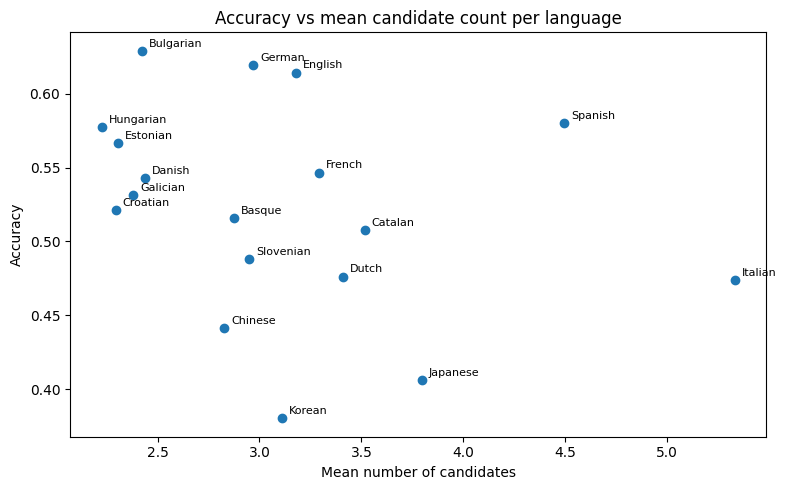

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(summary['mean_candidates'], summary['accuracy'])

# label each point with the language name
for lang, row in summary.iterrows():
    ax.annotate(lang, (row['mean_candidates'], row['accuracy']), 
                textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.set_xlabel('Mean number of candidates')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs mean candidate count per language')
plt.tight_layout()
plt.show()

# observation: candidate count does not explain the low scores for Korean and Japanese
# example: english and korean have the same mean candidate count, but english has much higher accuracy than korean 

In [10]:
# calculate lift over random baseline
df['random_baseline'] = 1 / df['num_candidates']
df['lift'] = df['correct'] - df['random_baseline']

lift_by_language = df.groupby('language')['lift'].mean()
print(lift_by_language.sort_values())

language
Korean      -0.001943
Chinese      0.044303
Croatian     0.061972
Japanese     0.076056
Galician     0.090717
Slovenian    0.097868
Danish       0.103830
Estonian     0.110204
Hungarian    0.110417
Basque       0.117057
Dutch        0.120958
Catalan      0.159969
French       0.179123
Bulgarian    0.193349
Italian      0.201526
English      0.229979
German       0.247146
Spanish      0.280636
Name: lift, dtype: float64


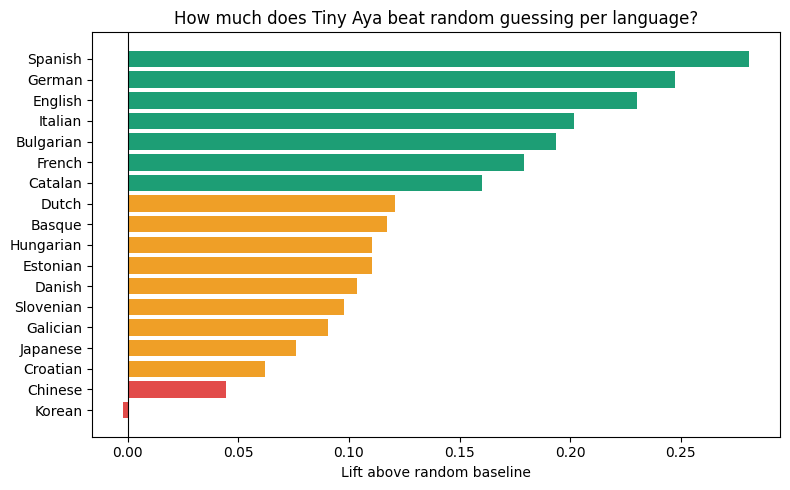

In [11]:
lift_by_language_sorted = lift_by_language.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#E24B4A' if v < 0.06 else '#EF9F27' if v < 0.13 else '#1D9E75' 
          for v in lift_by_language_sorted]

ax.barh(lift_by_language_sorted.index, lift_by_language_sorted.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Lift above random baseline')
ax.set_title('How much does Tiny Aya beat random guessing per language?')
plt.tight_layout()
plt.show()

# observation: tiny aya beats random guessing by a large margin for all languages, 
# but the lift is much smaller for korean and chinese than for other languages, which may explain the low accuracy scores for those languages.

In [12]:
# analyze only instances with 2 candidates (most common case)

easy = df[df['num_candidates'] == 2]
easy_accuracy = easy.groupby('language')['correct'].mean()
print(easy_accuracy.sort_values())

# observation: even when there are only 2 candidates, korean and chinese still have much lower accuracy than other languages, 
# which suggests that the model struggles with these languages in general, not just because of the number of candidates.

language
Korean       0.463849
Slovenian    0.475000
Chinese      0.539867
Japanese     0.540921
Croatian     0.557522
Basque       0.566434
Hungarian    0.575540
Catalan      0.584211
Galician     0.584906
Dutch        0.594104
Danish       0.604396
Estonian     0.625000
Bulgarian    0.655993
English      0.680387
Spanish      0.698462
French       0.700422
German       0.711538
Italian      0.758883
Name: correct, dtype: float64
